In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Data/updated dataset.csv")

In [6]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,deadline_date,avg_experience,avg_salary
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3.0,5.0,...,98.0,4.0,5.0,5.0,105800.0,128800.0,No,2023-11-12,4.0,117300.0
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1.0,4.0,...,134.0,2.0,1.0,0.0,105800.0,128800.0,No,2025-06-29,2.5,117300.0
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7.0,15.0,...,36.0,4.0,1.0,1.0,238800.0,274700.0,No,2026-01-24,11.0,256750.0
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1.0,4.0,...,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes,2020-12-09,2.5,100150.0
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6.0,9.0,...,43.0,3.0,1.0,1.0,186800.0,245400.0,Yes,2025-07-19,7.5,216100.0


In [7]:
df.shape

(113807, 31)

# LINEAR REGRESSION

In [8]:
df["avg_salary"]

0         117300.0
1         117300.0
2         256750.0
3         100150.0
4         216100.0
            ...   
113802    234800.0
113803    100500.0
113804    141200.0
113805    165050.0
113806    133700.0
Name: avg_salary, Length: 113807, dtype: float64

In [9]:
df["avg_salary"].isnull().sum()

np.int64(0)

In [10]:
target = 'avg_salary'

I selected avg_salary as the target because it shows the average salary for each job posting. As it is a num value, we can use it for a regression model

In [11]:
X = df.drop(columns=[
    "avg_salary",
    "salary_min_usd",
    "salary_max_usd",
    "layoff_within_12_months_flag"
])

y = df["avg_salary"]

We have drop salary_min_usd and salary_max_usd cols because avg_salary is derived from these cols<br>
layoff_within_12_months_flag col is droped because it is used in further prediction 


In [12]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag', 'deadline_date',
       'avg_experience', 'avg_salary'],
      dtype='str')

In [13]:
X= df[[
    "company_type",
    "sector",
    "job_role",
    "seniority_level",
    "years_experience_min",
    "years_experience_max",
    "work_mode",
    "salary_currency",
    "number_of_interview_rounds",
    "company_size_employees"
    
]]
y= df["avg_salary"]

In [14]:
print(X.shape)
print(y.shape)

(113807, 10)
(113807,)


### ENCODING

In [15]:
X["company_type"].unique()

<ArrowStringArray>
['MNC', 'Mid-size', 'Unicorn', 'FAANG-tier', 'Startup']
Length: 5, dtype: str

In [16]:
X= pd.get_dummies(X, columns= ["company_type"], drop_first=True, dtype=int)

Here we have done One-Hot Encoding

In [17]:
X["sector"].unique()

<ArrowStringArray>
[   'healthtech',   'cloud/infra', 'social/adtech',          'saas',
       'fintech', 'cybersecurity',   'crypto/web3',         'ai/ml',
    'e-commerce',        'edtech',     'logistics',        'gaming']
Length: 12, dtype: str

In [18]:
X= pd.get_dummies(X, columns= ["sector"], drop_first=True, dtype=int)

Here we have also use One-Hot Encoding

In [19]:
X["job_role"].unique()

<ArrowStringArray>
[                  'soc analyst',         'mobile engineer (ios)',
                   'qa engineer',            'research scientist',
               'product manager',                 'data engineer',
                   'ui designer',     'embedded systems engineer',
              'product designer',     'mobile engineer (android)',
             'platform engineer',           'full stack engineer',
              'backend engineer', 'application security engineer',
             'software engineer',     'machine learning engineer',
               'devops engineer',             'frontend engineer',
                  'data analyst',                 'product owner',
       'infrastructure engineer',     'associate product manager',
            'analytics engineer',                'data scientist',
     'technical program manager',                   'ux designer',
     'site reliability engineer',             'security engineer',
            'penetration tester',          

In [20]:
X= pd.get_dummies(X, columns= ["job_role"], drop_first=True, dtype=int)

One-Hot Encoding

In [21]:
X["seniority_level"].unique()

<ArrowStringArray>
['Mid', 'Lead', 'Entry', 'Senior', 'Intern', 'Principal']
Length: 6, dtype: str

In [22]:
seniority_replace= {"Intern":1, "Entry":2, "Mid":3, "Senior":4, "Lead":5, "Principal":6 }
X["seniority_level"]= X["seniority_level"].map(seniority_replace)

We have done ordinal encoding here because there is natural hierarchical order in seniority_level

In [23]:
X["work_mode"].unique()

<ArrowStringArray>
['hybrid', 'remote', 'onsite']
Length: 3, dtype: str

In [24]:
X= pd.get_dummies(X, columns= ["work_mode"], drop_first=True, dtype=int)

One-Hot Encoding

In [25]:
X["salary_currency"].unique()

<ArrowStringArray>
['EUR', 'USD', 'INR', 'GBP', 'BRL', 'ILS', 'SGD', 'CAD', 'AED', 'AUD']
Length: 10, dtype: str

In [26]:
X= pd.get_dummies(X, columns= ["salary_currency"], drop_first=True, dtype=int)

One-Hot Encoding

In [27]:
X.shape

(113807, 61)

In [28]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 113807 entries, 0 to 113806
Data columns (total 61 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   seniority_level                         113807 non-null  int64  
 1   years_experience_min                    113807 non-null  float64
 2   years_experience_max                    113807 non-null  float64
 3   number_of_interview_rounds              113807 non-null  float64
 4   company_size_employees                  113807 non-null  int64  
 5   company_type_MNC                        113807 non-null  int64  
 6   company_type_Mid-size                   113807 non-null  int64  
 7   company_type_Startup                    113807 non-null  int64  
 8   company_type_Unicorn                    113807 non-null  int64  
 9   sector_cloud/infra                      113807 non-null  int64  
 10  sector_crypto/web3                      113807 non-null

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
X_train.select_dtypes(include='object').columns

Index([], dtype='str')

In [31]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](61,)","[42648.12, -239.59, -182.75,...,-1700.11,-1398.79, 409.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](61,)","['seniority_level','years_experience_min','years_experience_max',..., 'salary_currency_INR','salary_currency_SGD','salary_currency_USD']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.682e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,61
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(58)


In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(mae)
print(mse)
print(rmse)
print(r2)

23560.940996415036
1937556570.5806274
44017.68474807174
0.5869237452221124


MAE: On average, the predicted salary differs from the actual salary by around 23.6K.<br>
MSE & RMSE: These values show that the model has some noticeable errors<br>
R²: The model is able to explain about 58.7% of the salary variation

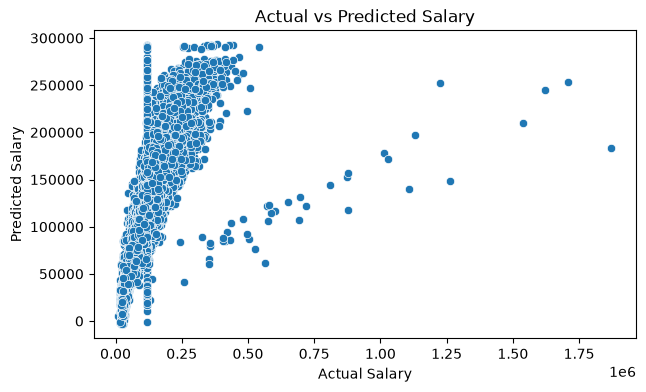

In [34]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

The plot shows that actual and predicted salaries have a positive relationship, but the points are quite spread out.
The model predicts lower salaries better, while higher salaries have more noticeable errors.

### CASE 2

In [35]:
X_layoff = X.copy()

In [36]:
df["layoff_within_12_months_flag"].value_counts()

layoff_within_12_months_flag
No     98884
Yes    14923
Name: count, dtype: int64

In [37]:
df['layoff_target'] = df['layoff_within_12_months_flag'].map({'Yes': 1,'No': 0})

In [38]:
df["layoff_target"].value_counts()

layoff_target
0    98884
1    14923
Name: count, dtype: int64

In [39]:
df["layoff_target"].isnull().sum()

np.int64(0)

In [40]:
print(df['layoff_target'].value_counts(normalize=True) * 100)

layoff_target
0    86.88745
1    13.11255
Name: proportion, dtype: float64


Target classes are imbalanced, so accuracy alone may not be sufficient to evaluate the model

In [41]:
X = df[[
    'company_type',
    'sector',
    'company_size_employees',
    'hq_country',
    'job_role',
    'seniority_level',
    'years_experience_min',
    'years_experience_max',
    'primary_programming_language',
    'work_mode',
    'visa_sponsorship_offered',
    'job_location_country',
    'job_location_city',
    'number_of_interview_rounds'
]]
y = df["layoff_target"]

### ENCODING SOME MORE COLUMNS

In [42]:
encoded_cols = pd.get_dummies(df[[ "hq_country", "primary_programming_language", "visa_sponsorship_offered", "job_location_country", "job_location_city"]], drop_first=True, dtype=int)

In [43]:
X_layoff[encoded_cols.columns]= encoded_cols

In [44]:
X_layoff.info()

<class 'pandas.DataFrame'>
RangeIndex: 113807 entries, 0 to 113806
Columns: 141 entries, seniority_level to job_location_city_unknown
dtypes: float64(3), int64(138)
memory usage: 122.4 MB


In [45]:
print(X_layoff.shape)
print(y.shape)

(113807, 141)
(113807,)


In [46]:
X_layoff.isnull().sum()

seniority_level                0
years_experience_min           0
years_experience_max           0
number_of_interview_rounds     0
company_size_employees         0
                              ..
job_location_city_Tel Aviv     0
job_location_city_Toronto      0
job_location_city_Vancouver    0
job_location_city_Waterloo     0
job_location_city_unknown      0
Length: 141, dtype: int64

In [47]:
X_layoff.head()

,seniority_level,years_experience_min,years_experience_max,number_of_interview_rounds,company_size_employees,company_type_MNC,company_type_Mid-size,company_type_Startup,company_type_Unicorn,sector_cloud/infra,...,job_location_city_San Francisco,job_location_city_Sao Paulo,job_location_city_Seattle,job_location_city_Singapore,job_location_city_Sydney,job_location_city_Tel Aviv,job_location_city_Toronto,job_location_city_Vancouver,job_location_city_Waterloo,job_location_city_unknown
0,3,3.0,5.0,4.0,146085,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,1.0,4.0,2.0,5882,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,5,7.0,15.0,4.0,186507,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,2,1.0,4.0,1.0,10930,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,4,6.0,9.0,3.0,42510,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
X_layoff_train, X_layoff_test, y_train, y_test = train_test_split(X_layoff, y, test_size=0.20, random_state=42, stratify=y)

In [49]:
X_layoff.dtypes

seniority_level                  int64
years_experience_min           float64
years_experience_max           float64
number_of_interview_rounds     float64
company_size_employees           int64
                                ...   
job_location_city_Tel Aviv       int64
job_location_city_Toronto        int64
job_location_city_Vancouver      int64
job_location_city_Waterloo       int64
job_location_city_unknown        int64
Length: 141, dtype: object

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_layoff_train_scaled = scaler.fit_transform(X_layoff_train)
X_layoff_test_scaled = scaler.transform(X_layoff_test)

# LOGISTIC REGRESSION

In [51]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_layoff_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(X_layoff_test_scaled)

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(accuracy_score(y_test, y_pred_logistic))
print(precision_score(y_test, y_pred_logistic))
print(recall_score(y_test, y_pred_logistic))
print(f1_score(y_test, y_pred_logistic))

0.8688603813373166
0.0
0.0
0.0


c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [53]:

print(y_test.value_counts())
print(pd.Series(y_pred_logistic).value_counts())

layoff_target
0    19777
1     2985
Name: count, dtype: int64
0    22762
Name: count, dtype: int64


We will use balancing here because the data had a big difference between the two classes. Class 0 had much more data than class 1, so without balancing the model it is mostly predicting class 0.

In [54]:
logistic_model = LogisticRegression(max_iter=1000, class_weight='balanced')
logistic_model.fit(X_layoff_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(X_layoff_test_scaled)

In [55]:
print(accuracy_score(y_test, y_pred_logistic))
print(precision_score(y_test, y_pred_logistic))
print(recall_score(y_test, y_pred_logistic))
print(f1_score(y_test, y_pred_logistic))

0.6047798963184254
0.16771697070204533
0.5082077051926298
0.25220282626766416


In [56]:
print(pd.Series(y_pred_logistic).value_counts())

0    13717
1     9045
Name: count, dtype: int64


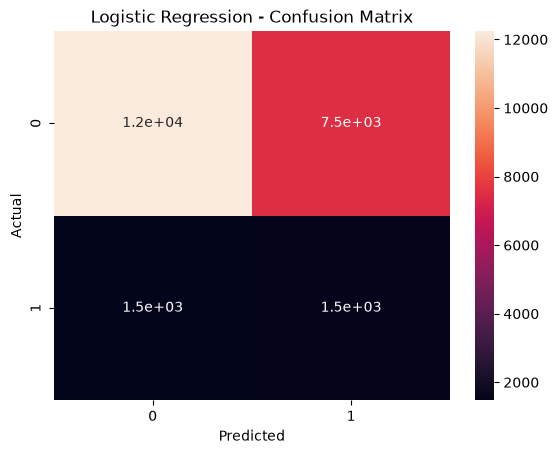

In [57]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

The model got many predictions right for class 0. But for class 1, some predictions were wrong. There are some predictions where model predict 1 for class 0

## DECISION TREE

In [58]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced')
tree_model.fit(X_layoff_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_layoff_test_scaled)

In [59]:
print(accuracy_score(y_test, y_pred_tree))
print(precision_score(y_test, y_pred_tree, zero_division=0))
print(recall_score(y_test, y_pred_tree, zero_division=0))
print(f1_score(y_test, y_pred_tree, zero_division=0))

0.7633775590897109
0.1613540197461213
0.1916247906197655
0.17519142419601838


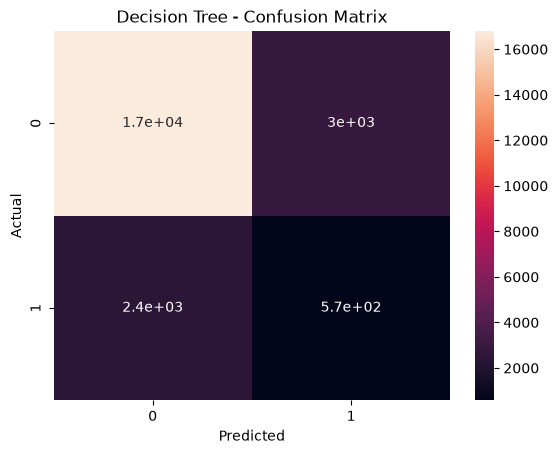

In [60]:
from sklearn.metrics import confusion_matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Compared to Logistic Regression, the Decision Tree is better at predicting class 0, but it misses more class 1 cases. Logistic Regression was better at identifying class 1, while the Decision Tree has more wrong predictions for class 1.